## Custom Middleware

In [5]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [7]:
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY')

from langchain.chat_models import init_chat_model

model = init_chat_model('anthropic:claude-sonnet-4-6')
model.invoke('Hi')
print("Cinebot's Brain is connected")

Cinebot's Brain is connected


### Shell Tool Middleware

In [9]:
from langchain.agents.middleware import ShellToolMiddleware, HostExecutionPolicy
from langchain.agents import create_agent

In [13]:
workspace_root = os.getcwd()

In [14]:
os.getcwd()

'd:\\Krish_Naik\\AgenticAI_3.0\\repository\\LangChain\\Middleware'

In [17]:
cinebot_shell_agent = create_agent(
    model=model,
    tools=[],  # no hand-written tools needed -- the shell session IS the capability here
    middleware=[
        ShellToolMiddleware(
            workspace_root=workspace_root,  # a real Colab path -- swap for /tmp/... if running elsewhere
            execution_policy=HostExecutionPolicy(),
            shell_command=[r"C:\Program Files\Git\bin\bash.exe"],
        ),
    ],
)

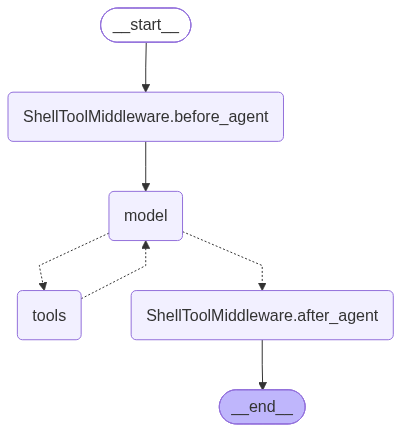

In [11]:
cinebot_shell_agent

In [18]:
result = cinebot_shell_agent.invoke({"messages": [("user", "Create a reports folder if the same doesn't exist.")]})

# Custom Middleware

#### Callbacks, Hooks, Middleware

Hooks are extension points in custom middleware that let you intercept, inspect, or modify agent execution at specific stages of the lifecycle.

In [19]:
# --- Core LangChain ---
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent, AgentState
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver

# --- Middleware building blocks -- every one used in this notebook ---
from langchain.agents.middleware import (
    AgentMiddleware,
    before_model,
    after_model,
    before_agent,
    after_agent,
    wrap_model_call,
    wrap_tool_call,
    hook_config,
    ModelRequest,
    ModelResponse,
)
from typing import Any, Callable
from typing_extensions import NotRequired
from langgraph.runtime import Runtime

In [20]:
@before_model
def log_before_model(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """Log every call about to be made to the model."""
    print(f"[LOG] About to call model with {len(state['messages'])} messages so far")
    return None  # None means "observed, nothing to change"

In [21]:
logged_agent = create_agent(model=model, tools=[], middleware=[log_before_model])

In [22]:
result = logged_agent.invoke({"messages": [("user", "Hi, How are you?")]})

[LOG] About to call model with 1 messages so far


#### Dynamic Model Selection

In [25]:
advanced_model = init_chat_model("anthropic:claude-sonnet-4-6")
basic_model = init_chat_model("anthropic:claude-haiku-4-5-20251001")

In [24]:
@wrap_model_call
def dynamic_model_selection(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """Use a cheap model for short conversations, a capable one once it gets complex."""
    message_count = len(request.state["messages"])
    chosen_model = advanced_model if message_count > 10 else basic_model
    return handler(request.override(model=chosen_model))

In [ ]:
cost_aware_agent = create_agent(
    model=basic_model,
    tools=[], # cinebot_tool
    middleware=[dynamic_model_selection]
)

result = cost_aware_agent.invoke({
    "messages": [("user", "Quick one — what's showing tonight?")]
})

### Class Based Middleware

In [28]:
class CallCounterMiddleware(AgentMiddleware):

    def __init__(self, warn_after: int = 3):
        self._num_calls = 0
        self.warn_after = warn_after

    def before_model(self, state, runtime):
        self._num_calls += 1
        if self._num_calls > self.warn_after:
            print("Bhai kaafi calls ho rhi hain. Keep Credit card ready.")
        return None